In [79]:
# Setup and imports
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pickle
from pathlib import Path
from typing import Tuple
from datetime import datetime

#add path path to data folder using sys.path
sys.path.append('../data_process/')

from data_process import load_dataset
from processors.cbc import CBC_REFERENCE_INTERVALS
from processors.outcomes import process_diagnosis

palette = sns.husl_palette(h=.7)
rc = {
    'figure.dpi': 300,
    'font.size': 6,
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'axes.labelsize': 6,  
    'legend.fontsize': 6,
    'axes.titlesize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'axes.edgecolor': 'k',
    'axes.linewidth': 0.5,
    'axes.grid': False,
    'axes.prop_cycle': plt.cycler(color=sns.husl_palette(h=.7)),
    'figure.figsize': (7, 2),
    'xtick.major.pad': -3,
    'ytick.major.pad': -3
}

plt.rcParams.update(rc)  # Apply the style
sns.set_theme(style="white", font='Arial', rc=rc)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
# DEFAULT_PATH = '/Users/aashnashah/Desktop/ssh_mount/data/EHRSHOT/meds_omop_ehrshot/'
# raw_df = load_dataset(DEFAULT_PATH)

In [65]:
if 'df' not in locals():
    df = pd.read_csv('../data/combined_subject_cbc_events.csv')
    print("Loading data...")
else:
    print("Data already loaded")

Data already loaded


# Testing


## Time Series Plots

/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_97131/499073328.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  heatmap_data = heatmap_data.applymap(bin_proportions)


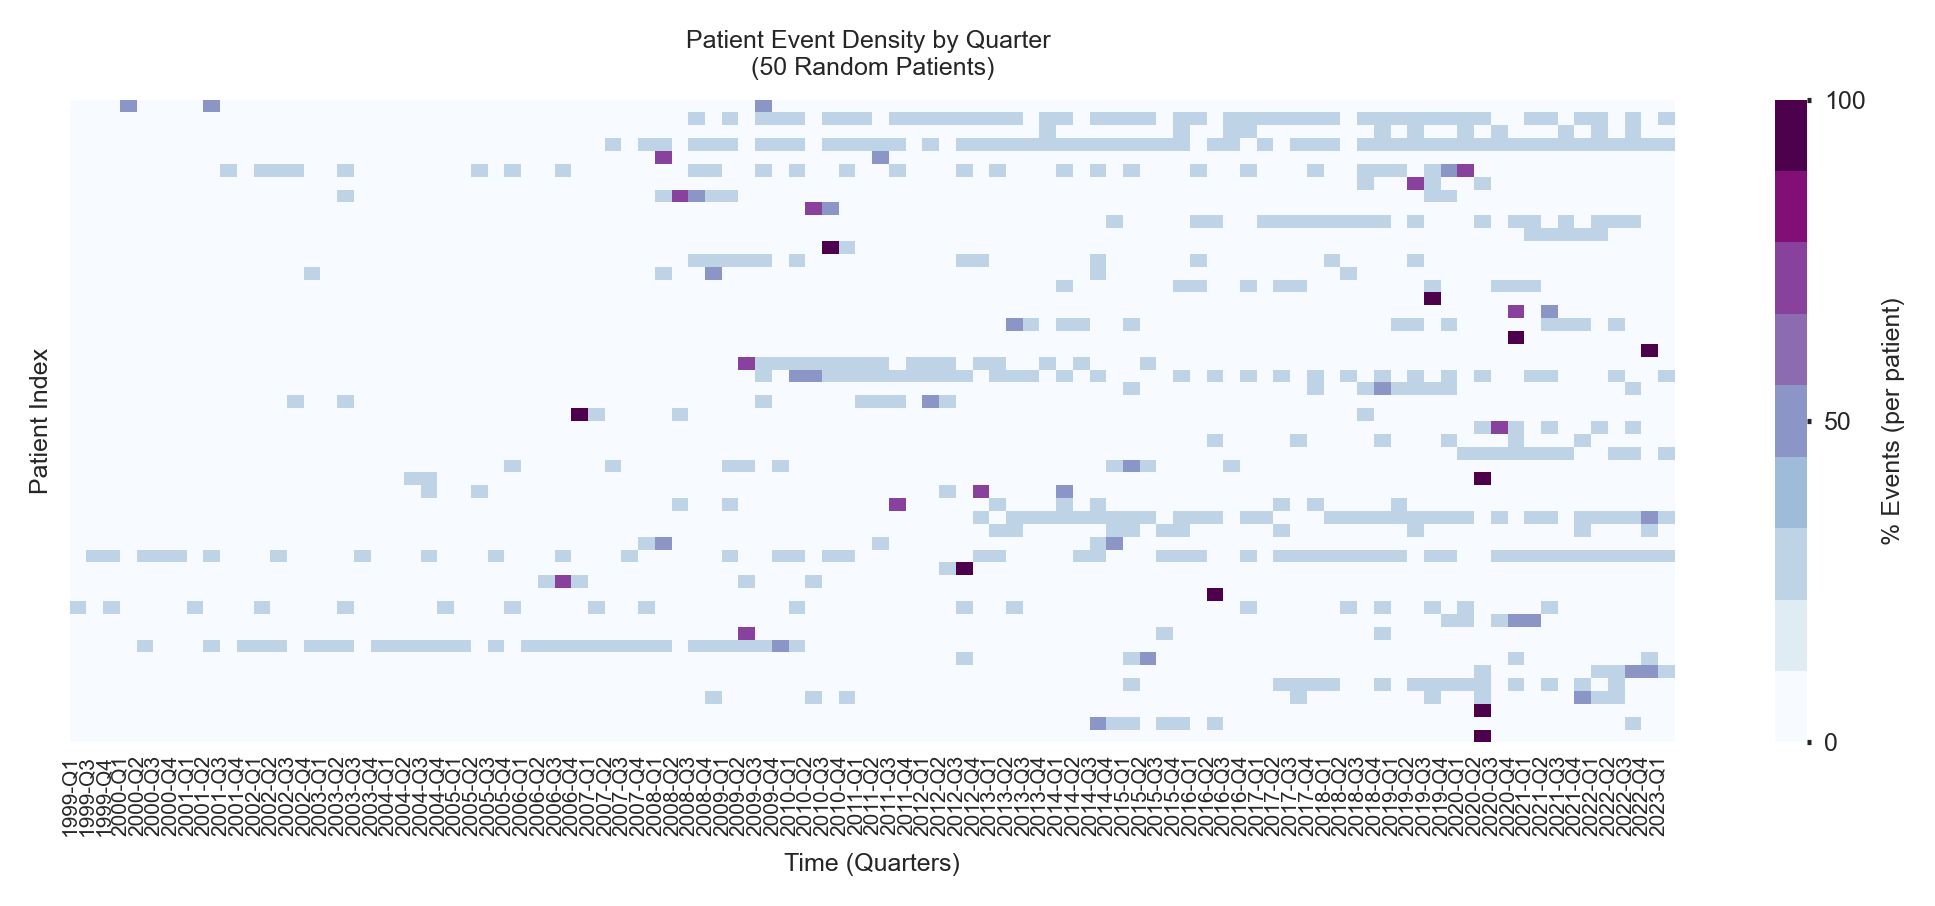

Total number of events: 19233
Average events per patient: 38.5
Date range: 1999-01-22 to 2023-02-06


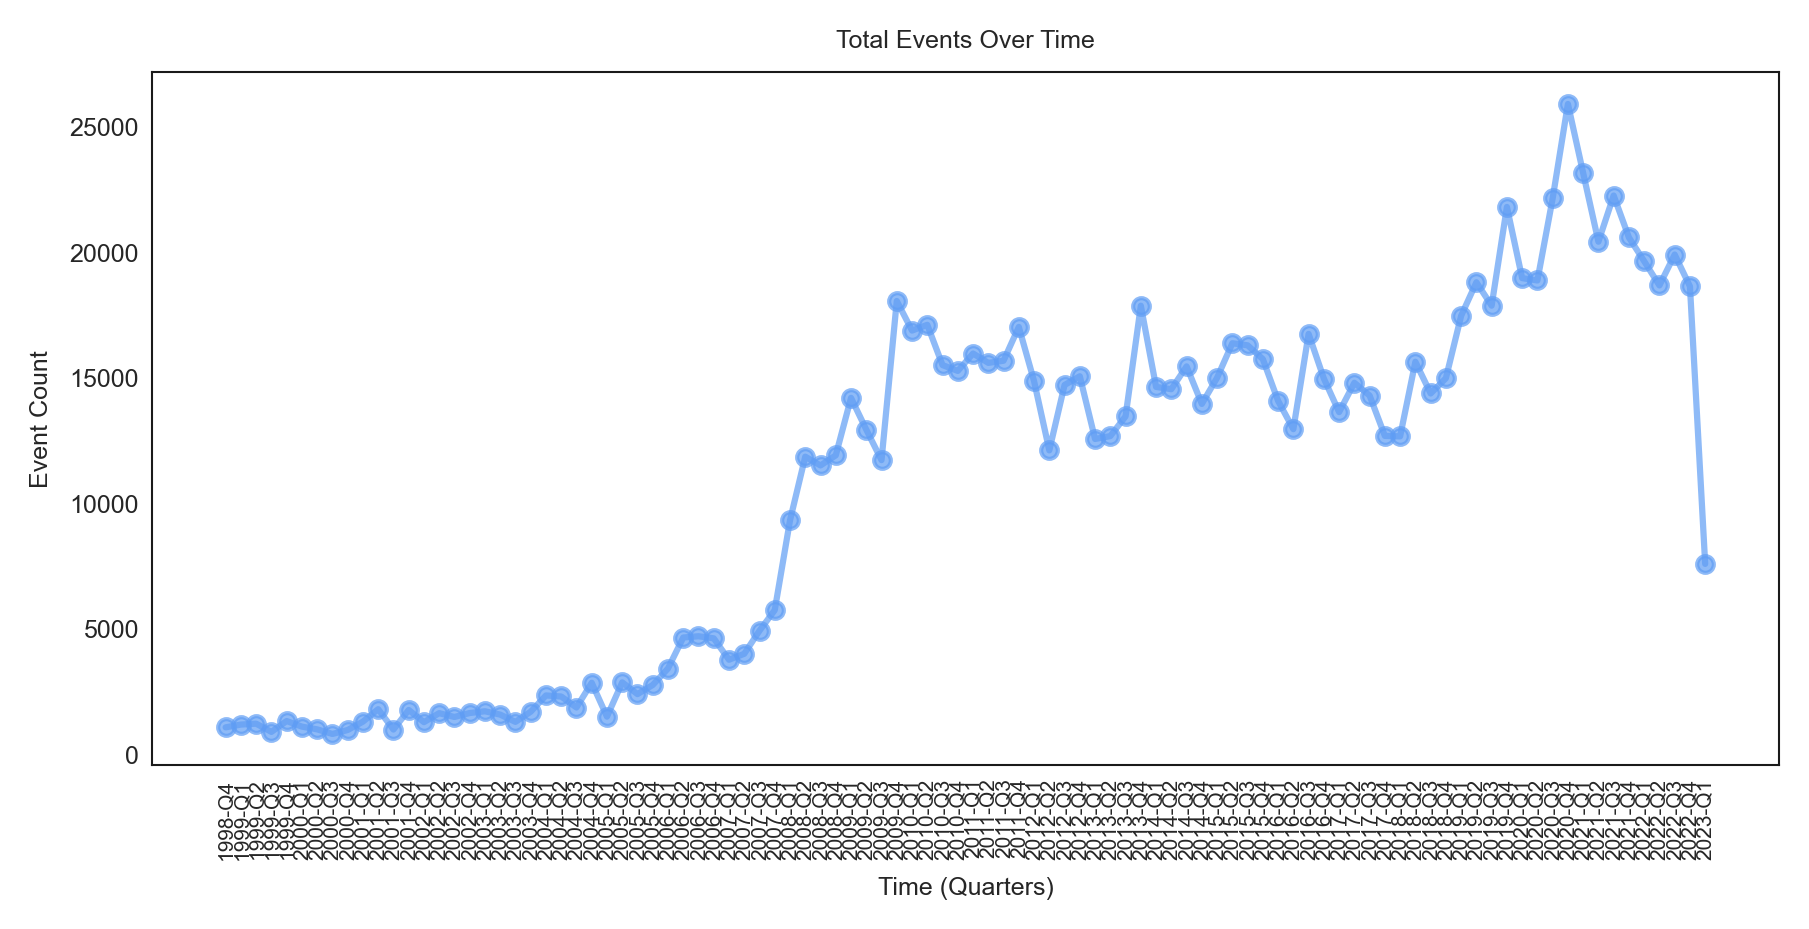

In [82]:
random_subjects = np.random.choice(df['subject_id'].unique(), size=50, replace=False)
plot_df = df[df['subject_id'].isin(random_subjects)].copy()
plot_df['time'] = pd.to_datetime(plot_df['time'])
plot_df["month"] = plot_df["time"].dt.to_period("M")
plot_df['time'] = pd.to_datetime(plot_df['time'])
plot_df['quarter'] = plot_df['time'].dt.to_period('Q')  # Q for quarter

heatmap_data = plot_df.groupby(["subject_id", "quarter"]).size().unstack(fill_value=0)
heatmap_data = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

def bin_proportions(x):
    if x == 0:
        return 0
    elif x <= 0.25:
        return 25
    elif x <= 0.5:
        return 50
    elif x <= 0.75:
        return 75
    else:
        return 100

heatmap_data = heatmap_data.applymap(bin_proportions)
plt.figure(figsize=(7, 3))

colors = ['#f7fbff', '#e0ecf4', '#bfd3e6', '#9ebcda', '#8c96c6', '#8c6bb1', '#88419d', '#810f76', '#4d004b']
ax = sns.heatmap(heatmap_data, 
            cmap=colors,
            linewidths=0,
            cbar_kws={ 
                'ticks': [0, 50, 100],
                'label': '% Events (per patient)'})
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(size=1, pad=3)  
plt.title('Patient Event Density by Quarter \n(50 Random Patients)')
plt.xlabel('Time (Quarters)')
plt.ylabel('Patient Index')

plt.xticks(np.arange(len(heatmap_data.columns)), 
          [f"{q.strftime('%Y-Q%q')}" for q in heatmap_data.columns], 
          rotation=90, fontsize=5)
plt.yticks([])
plt.tight_layout()
plt.show()

print(f"Total number of events: {plot_df.shape[0]}")
print(f"Average events per patient: {plot_df.shape[0]/500:.1f}")
print(f"Date range: {plot_df['time'].min().strftime('%Y-%m-%d')} to {plot_df['time'].max().strftime('%Y-%m-%d')}")

# -------------------
# Line Plot of Total Event Count Over Time
# -------------------

# Aggregate events over time
df['time'] = pd.to_datetime(df['time'])
df["Q"] = df["time"].dt.to_period("Q")
event_counts = df.groupby("Q").size()
event_counts.index = event_counts.index.strftime('%Y-Q%q')

plt.figure(figsize=(7, 3))
plt.plot(event_counts.index.astype(str), event_counts.values, marker="o", markersize=4, linestyle="-", alpha=0.7)
plt.title("Total Events Over Time")
plt.xlabel("Time (Quarters)")
plt.ylabel("Event Count")
plt.xticks(rotation=90, fontsize=5)
plt.show()


In [67]:
def analyze_variable(df: pd.DataFrame, variable: str):
    """
    Analyze a single variable with two side-by-side plots:
    1. Distribution for all events
    2. Distribution for patient-level averages
    """
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2)
    
    if pd.api.types.is_numeric_dtype(df[variable]):
        all_stats = df[variable].describe()
        patient_means = df.groupby('subject_id')[variable].mean()
        patient_stats = patient_means.describe()
        
        # Left plot: All events
        sns.histplot(data=df, x=variable, ax=ax1)
        ax1.axvline(all_stats['mean'], color='black', linestyle='--', alpha=0.8, 
                    label=f'Mean: {all_stats["mean"]:.1f}', linewidth=1)
        ax1.axvline(all_stats['50%'], color='grey', linestyle='--', alpha=0.8, 
                    label=f'Median: {all_stats["50%"]:.1f}', linewidth=1)
        ax1.set_title('Event-Level')
        ax1.legend(loc='upper left')
        
        # Right plot: Patient-level averages
        sns.histplot(data=patient_means, ax=ax2, color=palette[2])
        ax2.axvline(patient_stats['mean'], color='black', linestyle='--', alpha=0.8,
                    label=f'Mean: {patient_stats["mean"]:.1f}', linewidth=1)
        ax2.axvline(patient_stats['50%'], color='grey', linestyle='--', alpha=0.8,
                    label=f'Median: {patient_stats["50%"]:.1f}', linewidth=1)
        ax2.set_title('Patient-Level (Average)')
        ax2.legend(loc='upper left')
        
    else: # For categorical variables
        all_counts = df[variable].value_counts()
        total_events = len(df)
        
        sns.barplot(x=all_counts.index, y=all_counts.values, ax=ax1)
        ax1.set_title('Event-Level')
        ax1.set_ylabel('Count')
        
        # Add percentage labels
        for i, v in enumerate(all_counts.values):
            percentage = 100 * v / total_events
            ax1.text(i, v, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=4)
        
        # Right plot: Most frequent value per patient
        # For categorical variables, use mode instead of mean
        patient_modes = df.groupby('subject_id')[variable].agg(lambda x: x.mode()[0])
        patient_counts = patient_modes.value_counts()
        total_patients = len(patient_modes)
        
        sns.barplot(x=patient_counts.index, y=patient_counts.values, ax=ax2, color=palette[2])
        ax2.set_title('Patient-Level (Mode)')
        ax2.set_ylabel('Count')
        
        # Add percentage labels
        for i, v in enumerate(patient_counts.values):
            percentage = 100 * v / total_patients
            ax2.text(i, v, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=4)
    
    # Common settings for both plots
    for ax in [ax1, ax2]:
        plt.setp(ax.xaxis.get_majorticklabels(), ha='right')
        
    if variable == 'numeric_value':
        variable = df['code'].unique()[0]
    if variable == 'BMI_category' or variable == 'Race':
        variable = 'BMI Category'
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
   # fig.suptitle(f'{variable} Distribution', fontsize = 8) # bolded title
    plt.tight_layout()
    return fig, (ax1, ax2)
    


Demographic Analysis


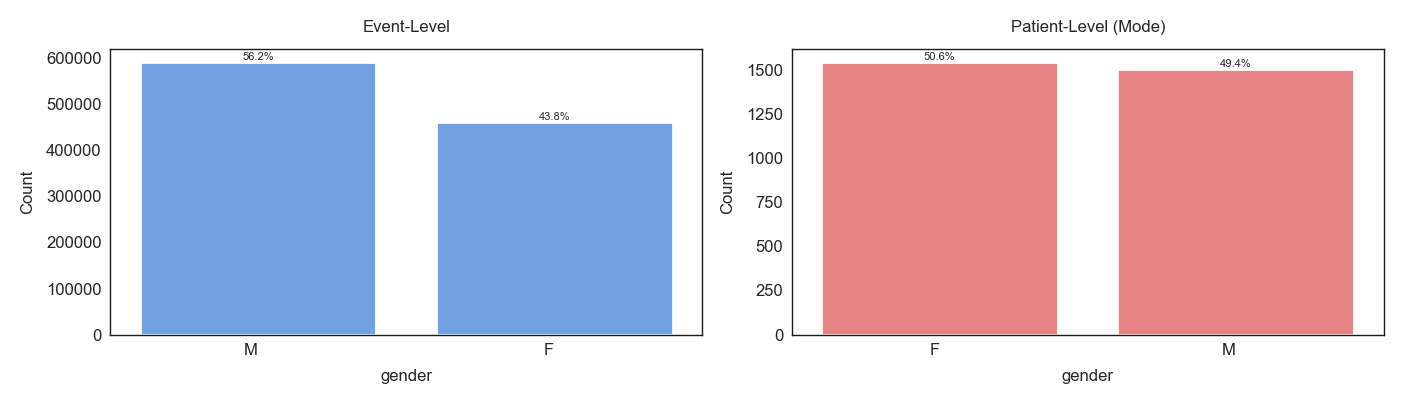

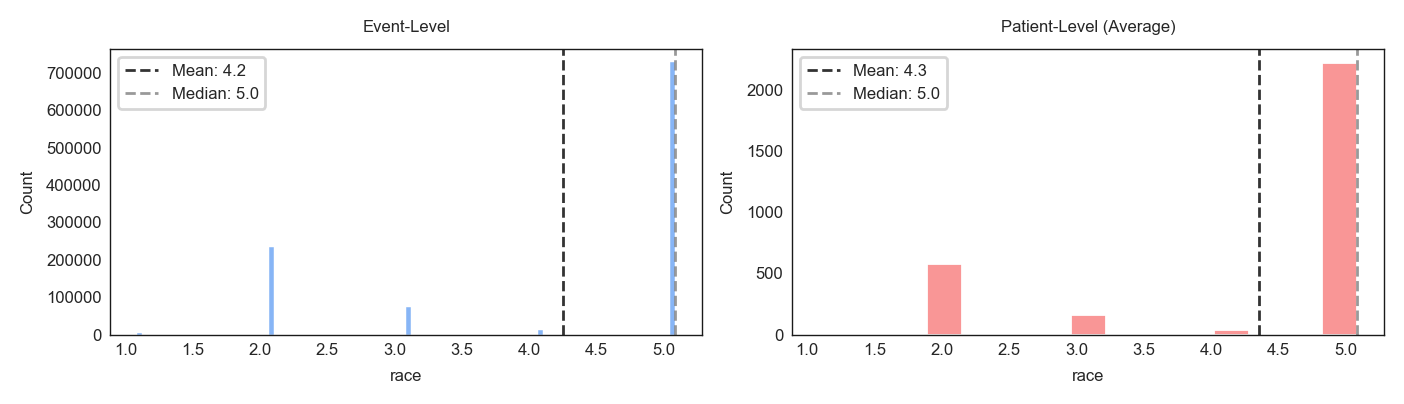

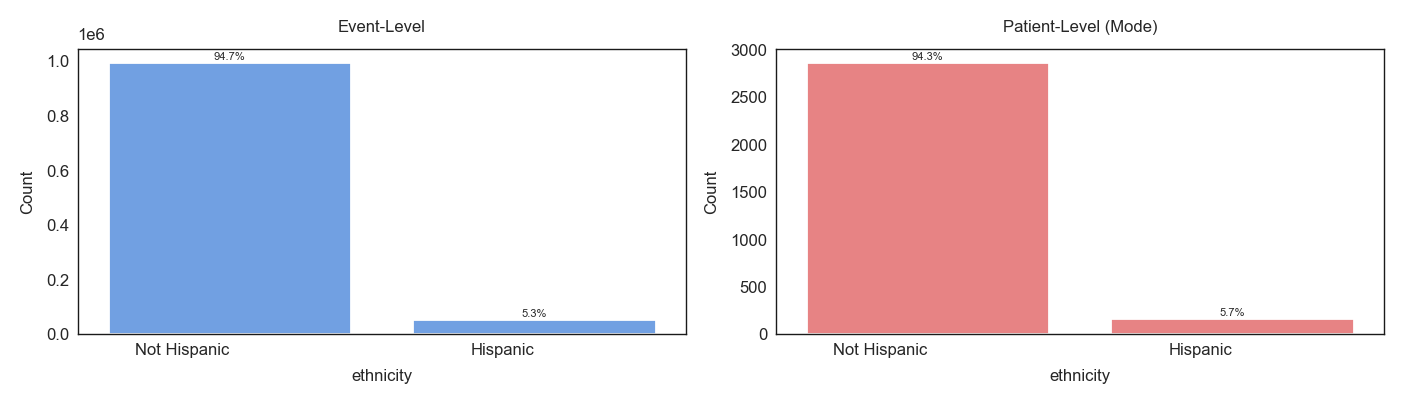

In [68]:

# Demographic analysis
print("\nDemographic Analysis")
for feature in ['gender', 'race', 'ethnicity']:    
    fig, (ax1, ax2) = analyze_variable(df, feature)
    plt.show()


BMI Analysis


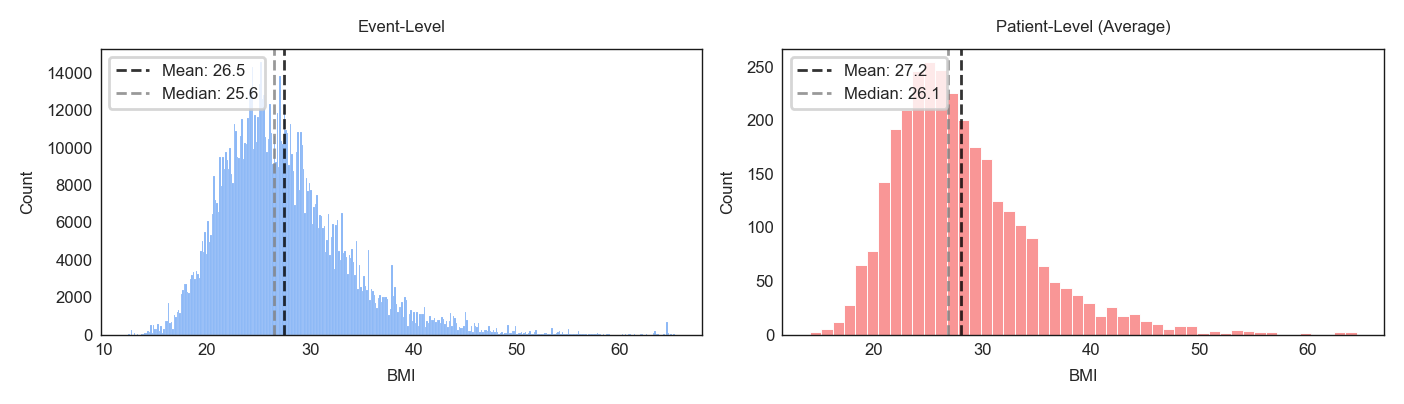

/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_97131/3058679908.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_97131/3058679908.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_97131/1763086603.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_97131/1763086603.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of tic

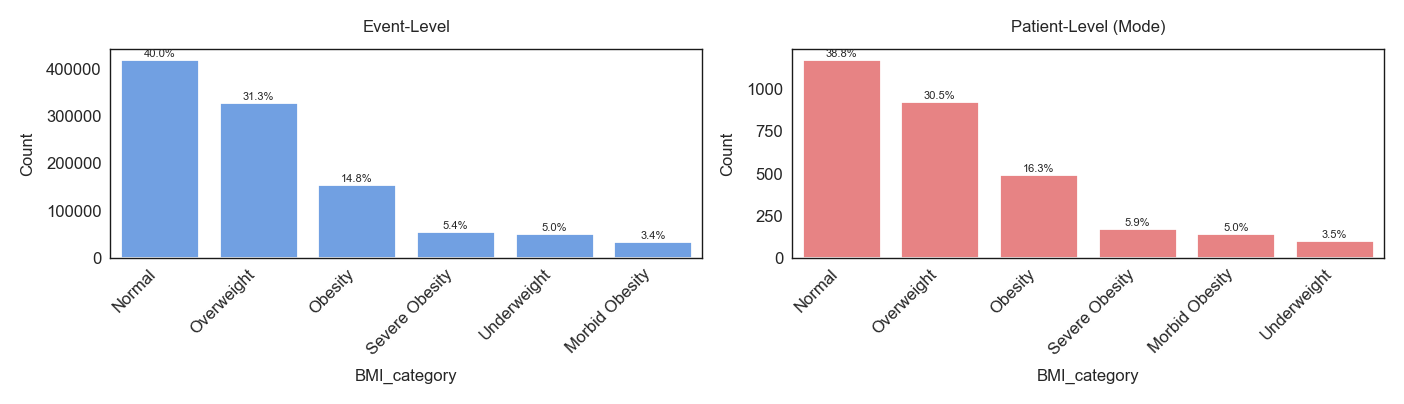

In [69]:
print("\nBMI Analysis")
for feature in ['BMI', 'BMI_category']:
    fig, (ax1, ax2) = analyze_variable(df, feature)
    if feature == 'BMI_category':
        # Rotate the x-axis labels
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    plt.show()

In [70]:
cbc_subject_stats = pd.read_csv('../results/summary_statistics/cbc_subject_statistics.csv')
setpoint_df = pd.read_csv('../results/setpoint_calculations/setpoints_gap:30_tests:5.csv')
demographics_df = pd.read_csv('../data/processed/demographics.csv')

merged = pd.merge(setpoint_df, cbc_subject_stats, on=['subject_id', 'code'], how='left')
setpoint_df = pd.merge(merged, demographics_df, on='subject_id', how='left')
setpoint_df.percentage_tests_within_reference = setpoint_df.percentage_tests_within_reference.str.rstrip('%').astype(float)

display(setpoint_df.head())
display(merged.head())

,subject_id,code,setpoint,uncertainty,model_type,num_tests_taken,last_test_time,num_tests_within_reference,percentage_tests_within_reference,days_between_first_and_last,avg_days_between_tests,min_days_between_tests,max_days_between_tests,gender,dob,race,ethnicity,observation_period_start_time,observation_period_end_time
0,115967104,HCT,35.675000,0.025796,gmm,5,2019-11-11 11:10:00,2,40.0,7590,1897.62,30.78,6678.71,F,1948-10-29 00:00:00,2,Not Hispanic,1998-08-05,2023-01-30
1,115967104,HGB,11.966667,0.010423,gmm,5,2019-11-11 11:10:00,3,60.0,7590,1897.62,30.78,6678.71,F,1948-10-29 00:00:00,2,Not Hispanic,1998-08-05,2023-01-30
2,115967104,MCH,28.350000,0.006359,gmm,5,2019-11-11 11:10:00,5,100.0,7590,1897.62,30.78,6678.71,F,1948-10-29 00:00:00,2,Not Hispanic,1998-08-05,2023-01-30
3,115967104,MCHC,33.174967,0.019811,gmm,5,2019-11-11 11:10:00,5,100.0,7590,1897.62,30.78,6678.71,F,1948-10-29 00:00:00,2,Not Hispanic,1998-08-05,2023-01-30
4,115967104,MCV,84.725001,0.015054,gmm,5,2019-11-11 11:10:00,5,100.0,7590,1897.62,30.78,6678.71,F,1948-10-29 00:00:00,2,Not Hispanic,1998-08-05,2023-01-30


,subject_id,code,setpoint,uncertainty,model_type,num_tests_taken,last_test_time,num_tests_within_reference,percentage_tests_within_reference,days_between_first_and_last,avg_days_between_tests,min_days_between_tests,max_days_between_tests
0,115967104,HCT,35.675000,0.025796,gmm,5,2019-11-11 11:10:00,2,40.00%,7590,1897.62,30.78,6678.71
1,115967104,HGB,11.966667,0.010423,gmm,5,2019-11-11 11:10:00,3,60.00%,7590,1897.62,30.78,6678.71
2,115967104,MCH,28.350000,0.006359,gmm,5,2019-11-11 11:10:00,5,100.00%,7590,1897.62,30.78,6678.71
3,115967104,MCHC,33.174967,0.019811,gmm,5,2019-11-11 11:10:00,5,100.00%,7590,1897.62,30.78,6678.71
4,115967104,MCV,84.725001,0.015054,gmm,5,2019-11-11 11:10:00,5,100.00%,7590,1897.62,30.78,6678.71


In [71]:
def plot_distribution_with_statistics(data, gender_idx, ax, color=None, title='', ylabel='Count', is_setpoint=False):
    """
    Creates a histogram with mean and median lines, and optionally reference intervals.
    """
    stats = data.describe()
    plot_args = {'data': data} if gender_idx == 0 else {'data': data, 'color': palette[2]}
    sns.histplot(ax=ax, **plot_args)
    
    ax.axvline(stats['mean'], color='black', linestyle='--', alpha=0.8,
               label=f'Mean: {stats["mean"]:.1f}', linewidth=1)
    ax.axvline(stats['50%'], color='grey', linestyle='--', alpha=0.8,
               label=f'Median: {stats["50%"]:.1f}', linewidth=1)
    
    if gender_idx == 1:
        title = title.split('\n \n')[1]
        
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper left')

def get_gender_data(df, setpoint_df, gender, variable, code):
    """
    Gets filtered data for a specific gender.
    """
    gender_df = df[df['gender'] == gender].copy()
    gender_setpoints = setpoint_df[
        (setpoint_df['gender'] == gender) & 
        (setpoint_df['code'] == code)
    ].copy()
    lower_b, upper_b, unit = CBC_REFERENCE_INTERVALS[code][gender]
    gender_setpoints['within_reference'] = gender_setpoints['setpoint'].apply(lambda x: 1 if x >= lower_b and x <= upper_b else 0)
    return gender_df, gender_setpoints

def add_reference_intervals(ax, code, gender, show_label=True):
    """
    Adds reference interval lines to a plot if available for the given CBC code and gender.
    
    Args:
        ax: matplotlib axis
        code: CBC code
        gender: 'F' or 'M'
        show_label: whether to show the reference interval label
    """
    if code in CBC_REFERENCE_INTERVALS and gender in CBC_REFERENCE_INTERVALS[code]:
        lower_b, upper_b, unit = CBC_REFERENCE_INTERVALS[code][gender]
        if show_label:
            ax.axvline(lower_b, color='red', linestyle='--', alpha=0.8,
                      label=f'Ref: {lower_b}-{upper_b}', linewidth=1)
            ax.axvline(upper_b, color='red', linestyle='--', alpha=0.8, linewidth=1)
            ax.legend(loc='upper left')
        else:
            ax.axvline(lower_b, color='red', linestyle='--', alpha=0.8, linewidth=1)
            ax.axvline(upper_b, color='red', linestyle='--', alpha=0.8, linewidth=1)
        ax.set_xlabel(f'{code} {unit}')

def cbc_analyze_variable(df: pd.DataFrame, setpoint_df: pd.DataFrame, variable: str, code: str):
    """
    Analyze a single variable with separate plots for each gender:
    """
    fig, axes = plt.subplots(2, 3, figsize=(9, 3), sharex=True, sharey='col')

    # Process each gender
    percentage_in_reference = {}
    for gender_idx, (gender_label, gender) in enumerate({'Male': 'M', 'Female': 'F'}.items()):
        # Get filtered data for current gender
        gender_df, gender_setpoints = get_gender_data(df, setpoint_df, gender, variable, code)
        
        if pd.api.types.is_numeric_dtype(gender_df[variable]):
            # Calculate patient means
            patient_means = gender_df.groupby('subject_id')[variable].mean()
            patient_majority_in_reference = gender_df.groupby('subject_id')['within_reference'].agg(lambda x: x.mode()[0])   
            
            # Create the three plots
            plot_distribution_with_statistics(
                gender_df[variable], 
                gender_idx,
                axes[gender_idx, 0],
                title=f'Event-Level\n \nN = {len(gender_df)} \n # in Reference Range = {sum(gender_df['within_reference'])}'                             
            )
            
            plot_distribution_with_statistics(
                patient_means,
                gender_idx,
                axes[gender_idx, 1],
                title=f'Patient-Level (Averages)\n \nN = {len(patient_means)} \n # in Reference Range = {sum(patient_majority_in_reference)}'               
            )
            
            plot_distribution_with_statistics(
                gender_setpoints['setpoint'],
                gender_idx,
                axes[gender_idx, 2],
                title=f'Patient-Level (Setpoints)\n \nN = {gender_setpoints.subject_id.nunique()} \n # in Reference Range = {sum(gender_setpoints['within_reference'])}',
                is_setpoint=True
            )
            percentage_in_reference[gender] = sum(gender_setpoints['within_reference']) / len(gender_setpoints.subject_id.unique())
            # Add reference intervals to all plots, but only show label on first plot
            for i, ax in enumerate(axes[gender_idx]):
                add_reference_intervals(ax, code, gender, show_label=(i==0))

            # Add gender label
            axes[gender_idx, 2].text(
                1.05, 0.5, gender_label, transform=axes[gender_idx, 2].transAxes,
                rotation=-90, va='center', ha='center',
            )
            
    plt.tight_layout()
    return fig, axes, percentage_in_reference

('HCT',)
3030


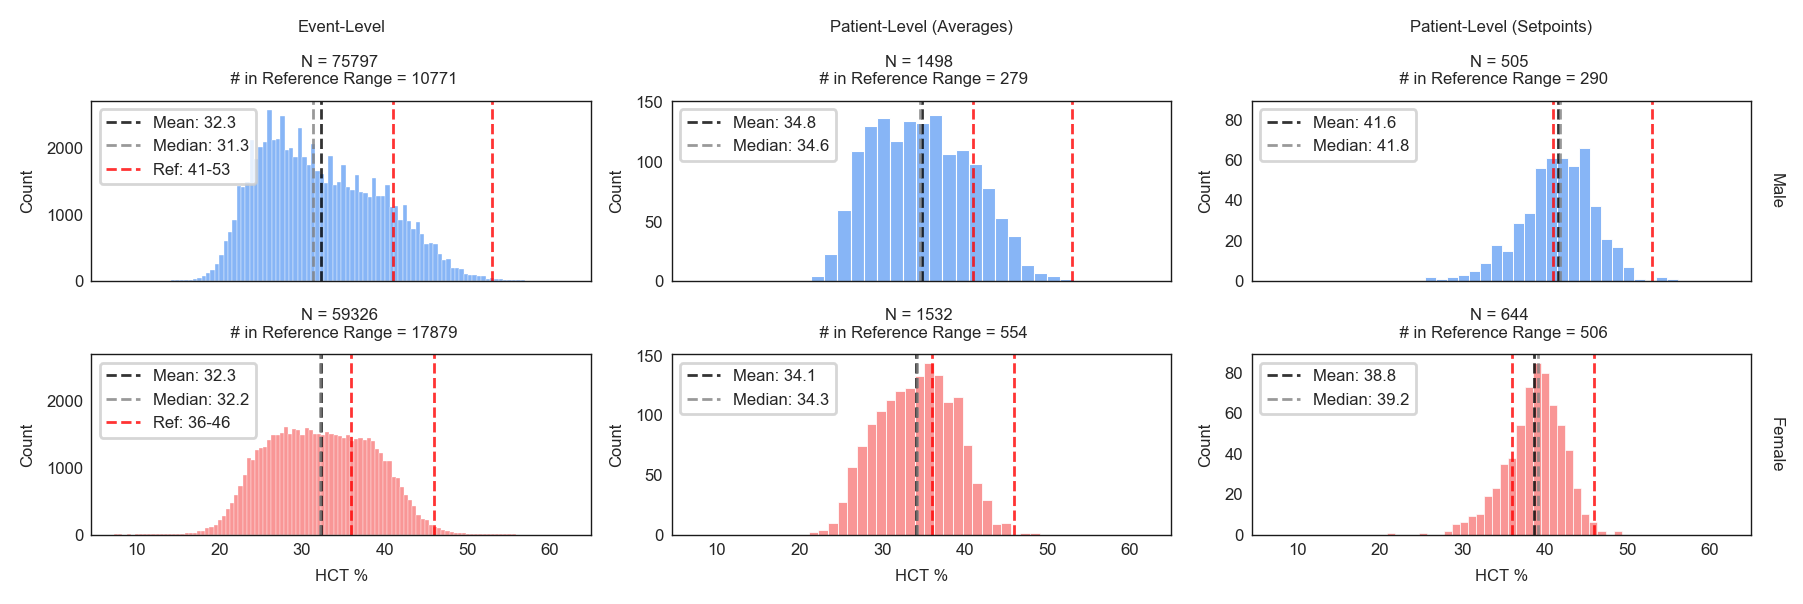

('HGB',)
2987


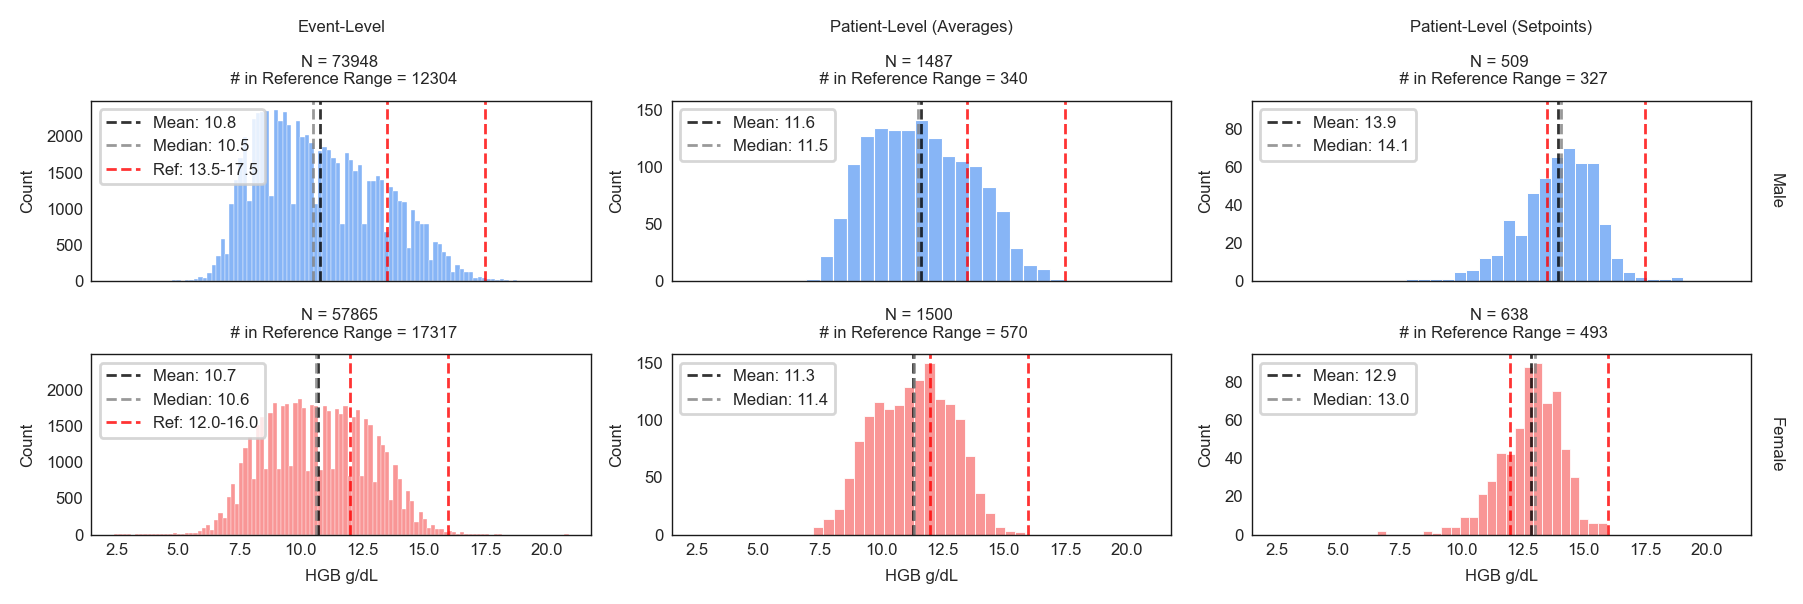

('MCH',)
2948


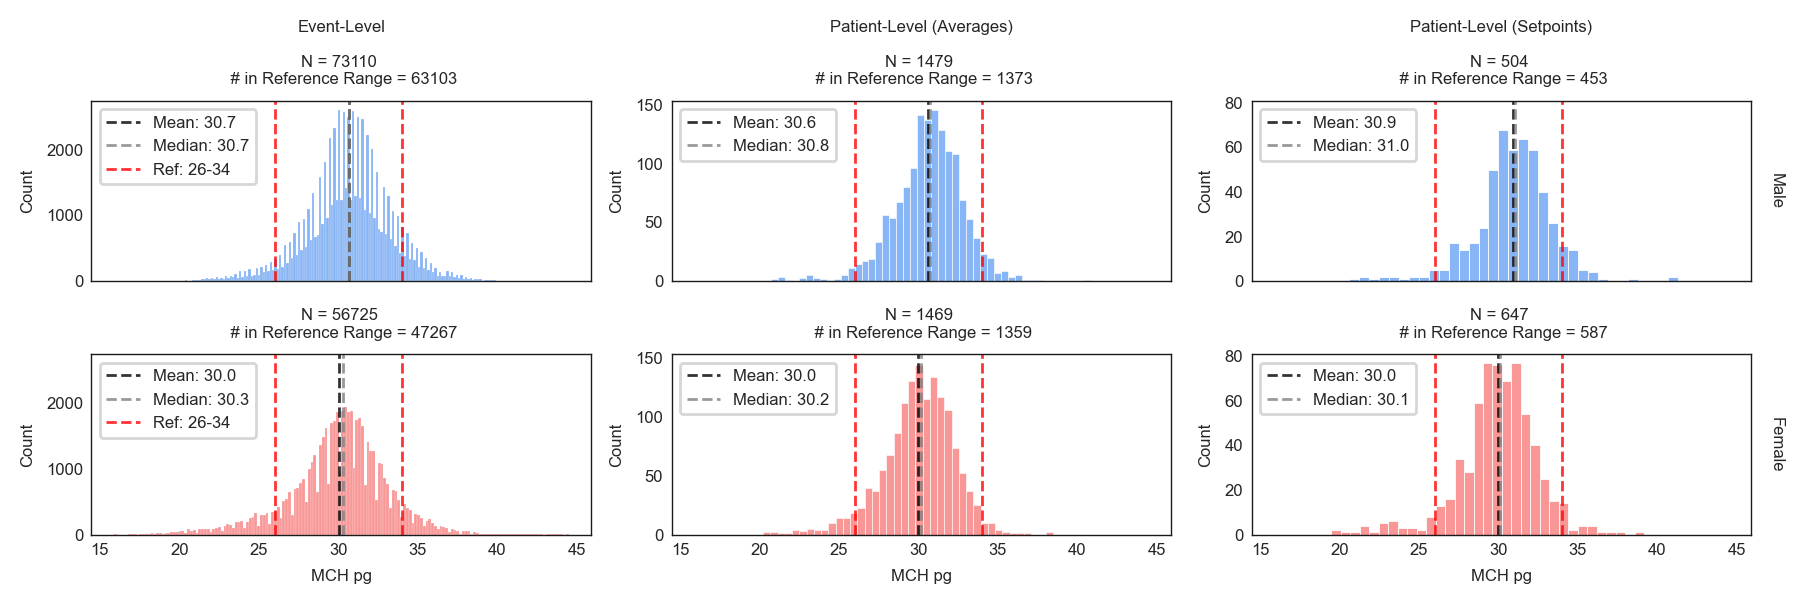

('MCHC',)
2952


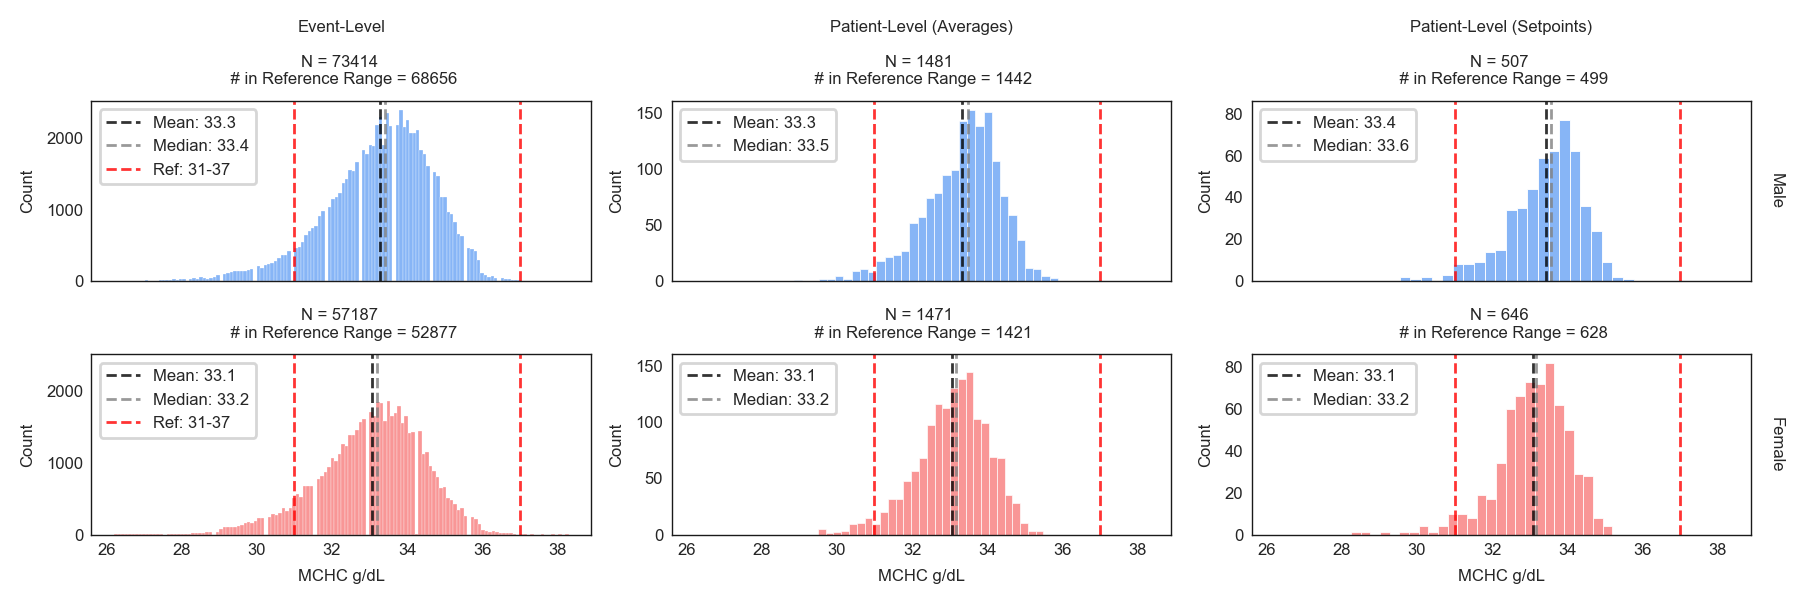

('MCV',)
2953


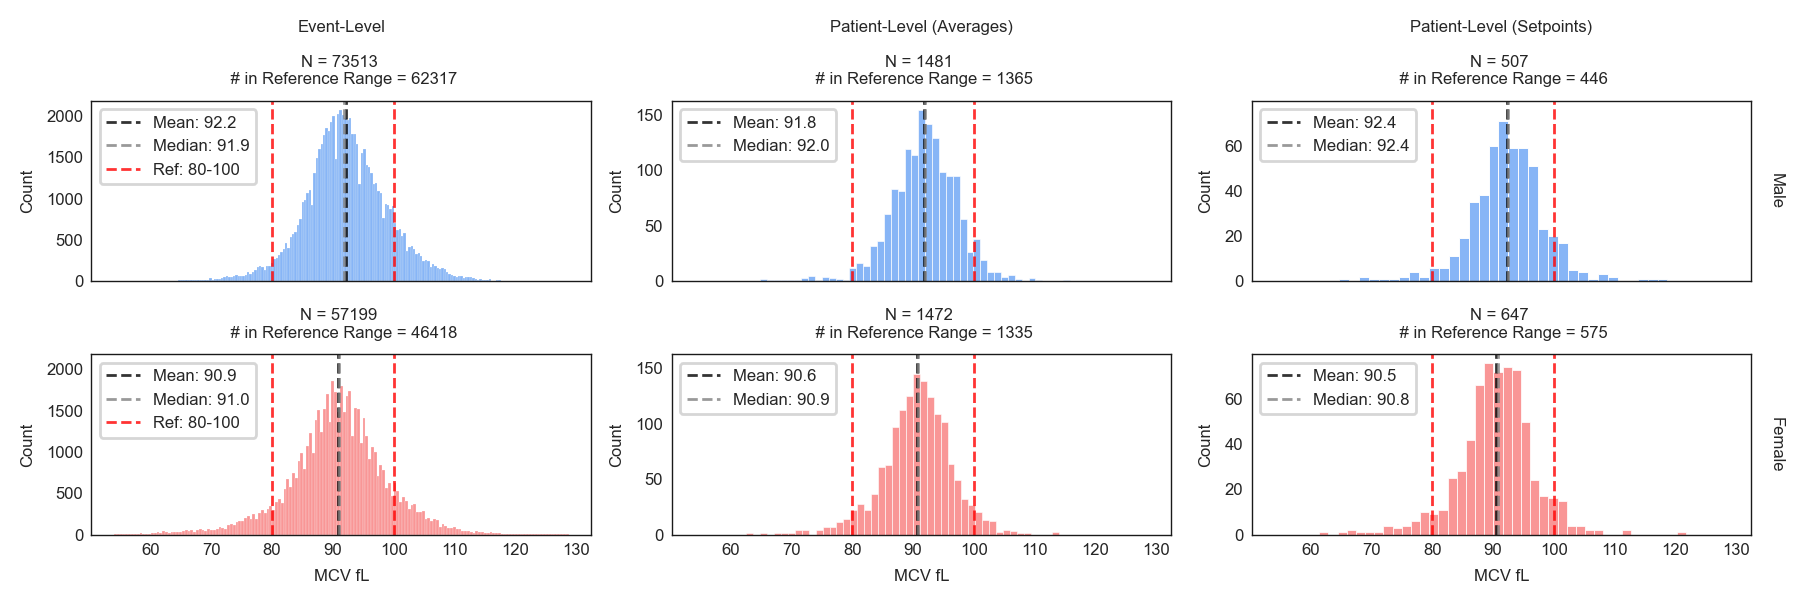

('PLT',)
2965


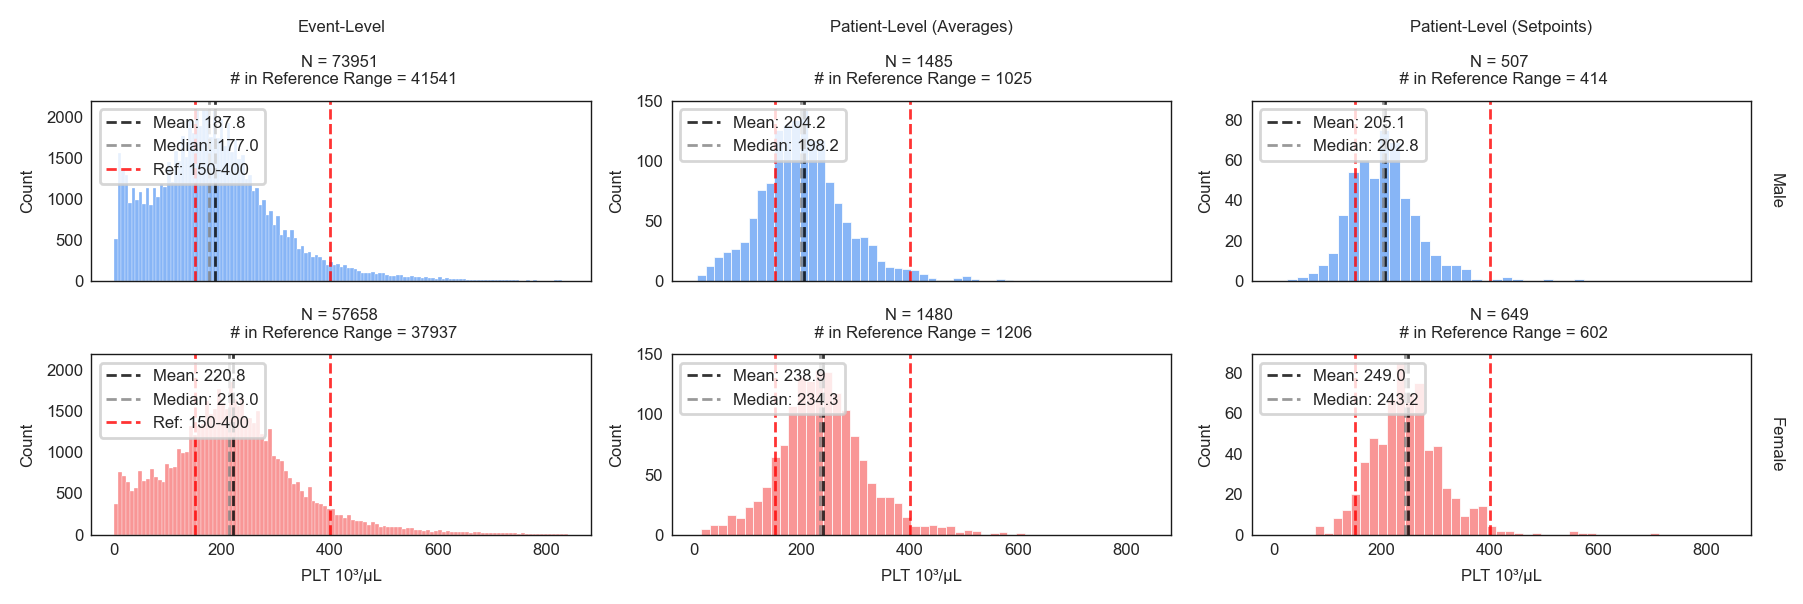

('RBC',)
2953


/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_97131/1324305705.py:106: UserWarning: Glyph 8310 (\N{SUPERSCRIPT SIX}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aashnashah/opt/anaconda3/envs/setpoints/lib/python3.13/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8310 (\N{SUPERSCRIPT SIX}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


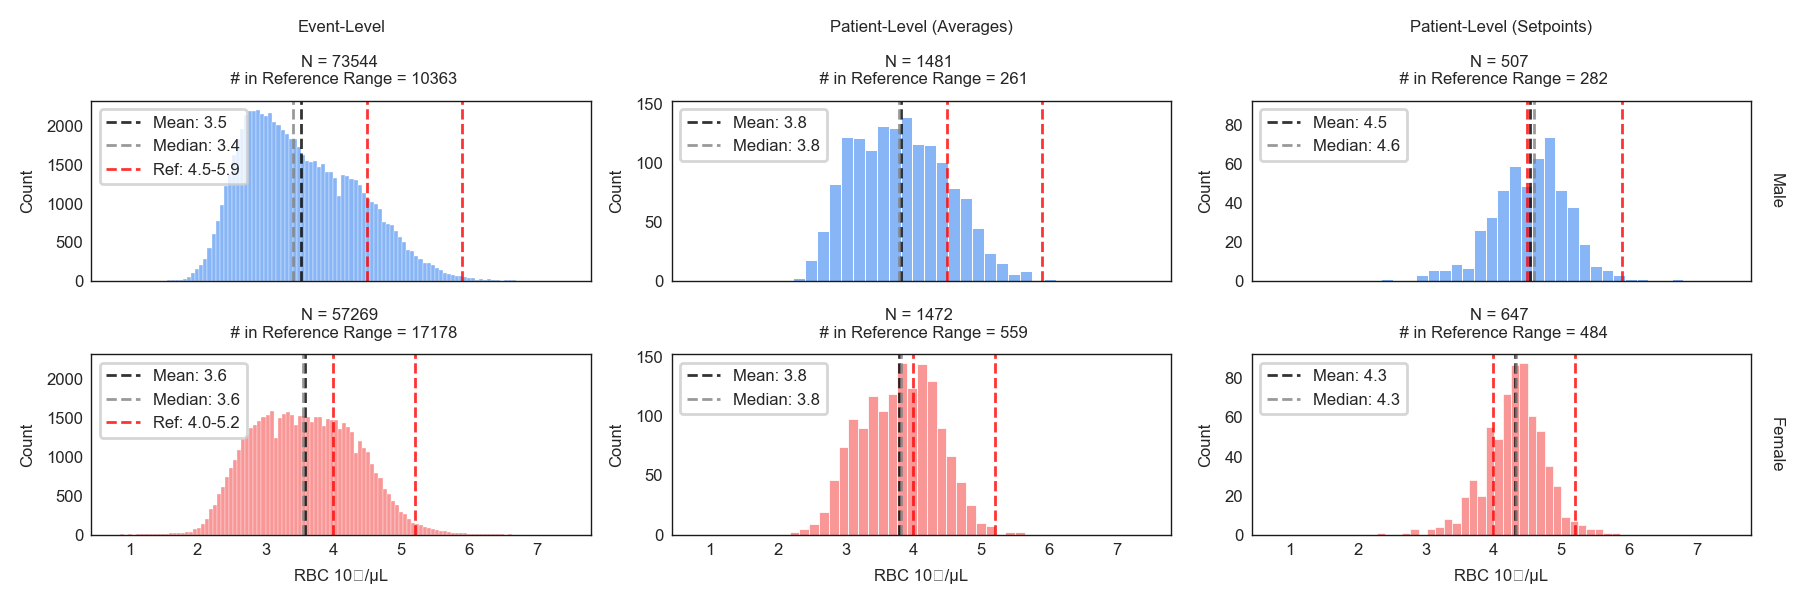

('RDW',)
2953


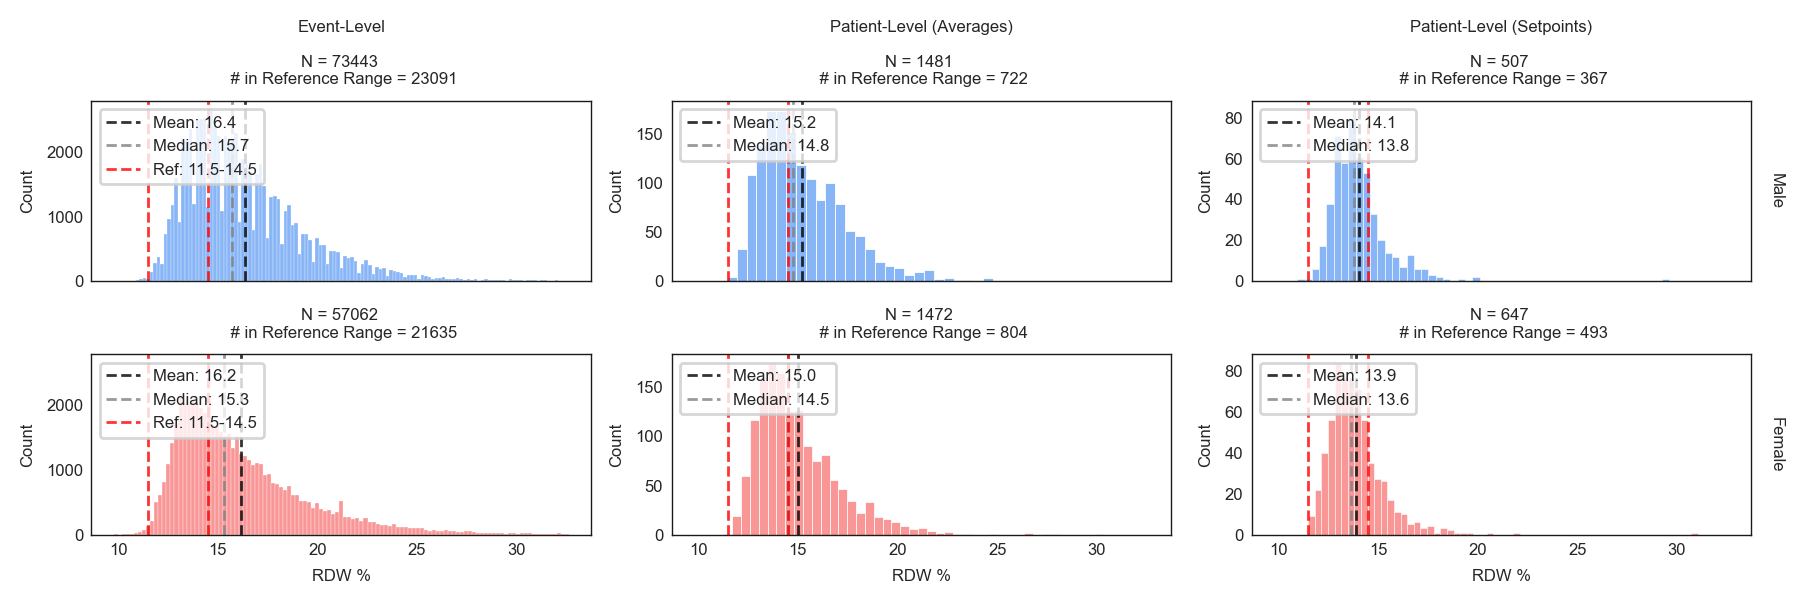

('WBC',)
78


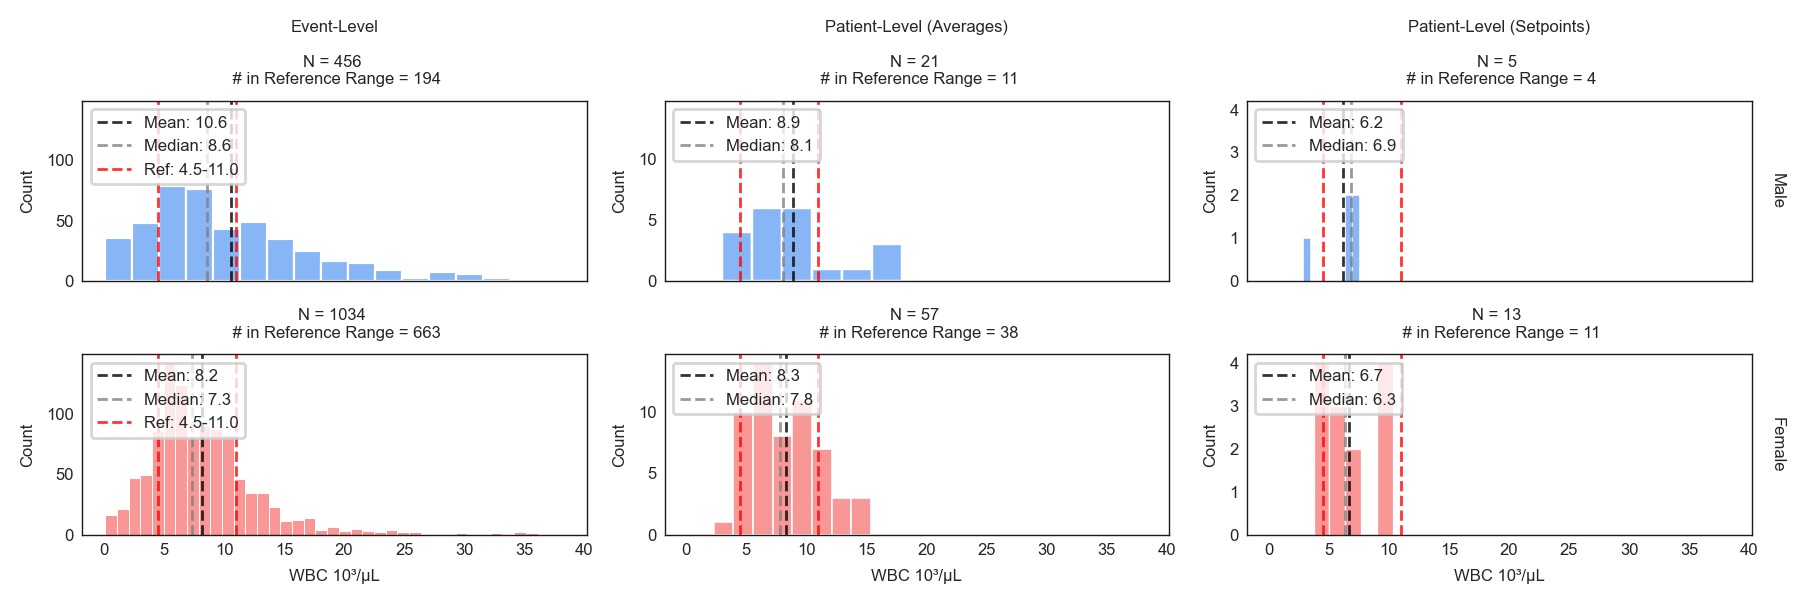

In [72]:
proportions_in_reference = {}
for group, group_df in df.groupby(['code']):
    print(group)
    print(len(group_df.subject_id.unique()))
    fig, axes, percentage_in_reference = cbc_analyze_variable(group_df, setpoint_df, 'numeric_value', group[0])
    proportions_in_reference[group] = percentage_in_reference
    plt.tight_layout()
    plt.show()

    Code  Gender  Proportion in Reference
0    HCT    Male                 0.574257
1    HGB    Male                 0.642436
2    MCH    Male                 0.898810
3   MCHC    Male                 0.984221
4    MCV    Male                 0.879684
5    PLT    Male                 0.816568
6    RBC    Male                 0.556213
7    RDW    Male                 0.723866
8    WBC    Male                 0.800000
9    HCT  Female                 0.785714
10   HGB  Female                 0.772727
11   MCH  Female                 0.907264
12  MCHC  Female                 0.972136
13   MCV  Female                 0.888717
14   PLT  Female                 0.927581
15   RBC  Female                 0.748068
16   RDW  Female                 0.761978
17   WBC  Female                 0.846154


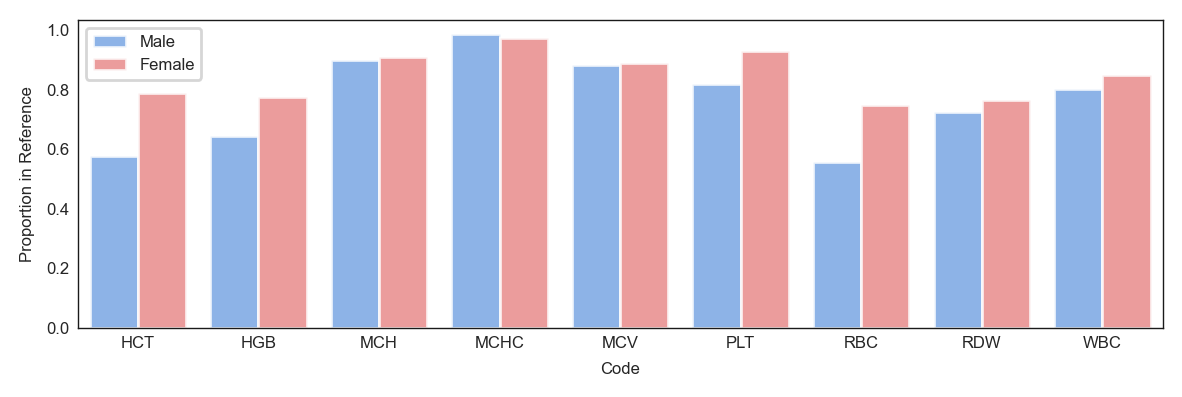

In [76]:
proportions_df = pd.DataFrame(proportions_in_reference).T.reset_index().rename(columns={'level_0': 'Code', 'M': 'Male', 'F': 'Female'})
proportions_df = proportions_df.melt(id_vars=('Code'), value_vars=('Male', 'Female'), var_name='Gender', value_name='Proportion in Reference')
print(proportions_df)
colors = (palette[0], palette[2])
# plot the proportions in reference for each code
sns.barplot(data=proportions_df, x='Code', y='Proportion in Reference', hue='Gender', alpha=0.8, palette=colors)
plt.legend(loc='upper left')
plt.show()


In [83]:
diagnosis_df = pd.read_csv('../data/processed/diagnosis.csv')
combined_cbc_df = pd.read_csv('../data/combined_subject_cbc_events.csv')
diagnosis_df = diagnosis_df[diagnosis_df['subject_id'].isin(combined_cbc_df['subject_id'])]

diseases = ['chronic_heart_disease', 'chronic_kidney_disease', 'type_2_diabetes', 'MACE', 'MDS', 'osteoporosis']
diagnosis_df = diagnosis_df[diagnosis_df[diseases].any(axis=1)]
diagnosis_df[diseases].sum()

# for each disease, get the count of each unique subjects where their value is 1 
for disease in diseases:
    print(disease)
    print(diagnosis_df[diagnosis_df[disease] == 1].subject_id.nunique() / len(diagnosis_df.subject_id.unique()))
# get the count of each disease
# for each disease, get the count of each unique subjects where their value is 1 


chronic_heart_disease
791
chronic_kidney_disease
930
type_2_diabetes
554
MACE
1156
MDS
66
osteoporosis
406


chronic_heart_disease     14552
chronic_kidney_disease    17907
type_2_diabetes            7521
MACE                      17869
MDS                        2666
osteoporosis               3652
dtype: int64

In [89]:

# for each disease, get the count of each unique subjects where their value is 1 
for disease in diseases:
    print(disease)
    print(diagnosis_df[diagnosis_df[disease] == 1].subject_id.nunique() / 6739)
# get the count of each disease

chronic_heart_disease
0.11737646535094227
chronic_kidney_disease
0.13800267101943908
type_2_diabetes
0.08220804273631102
MACE
0.17153880397685117
MDS
0.009793737943315032
osteoporosis
0.060246327348271254


/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_97131/2623699546.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
/var/folders/bs/d4qy9fyd0qx3k7_5vtrvzv580000gn/T/ipykernel_97131/2623699546.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')


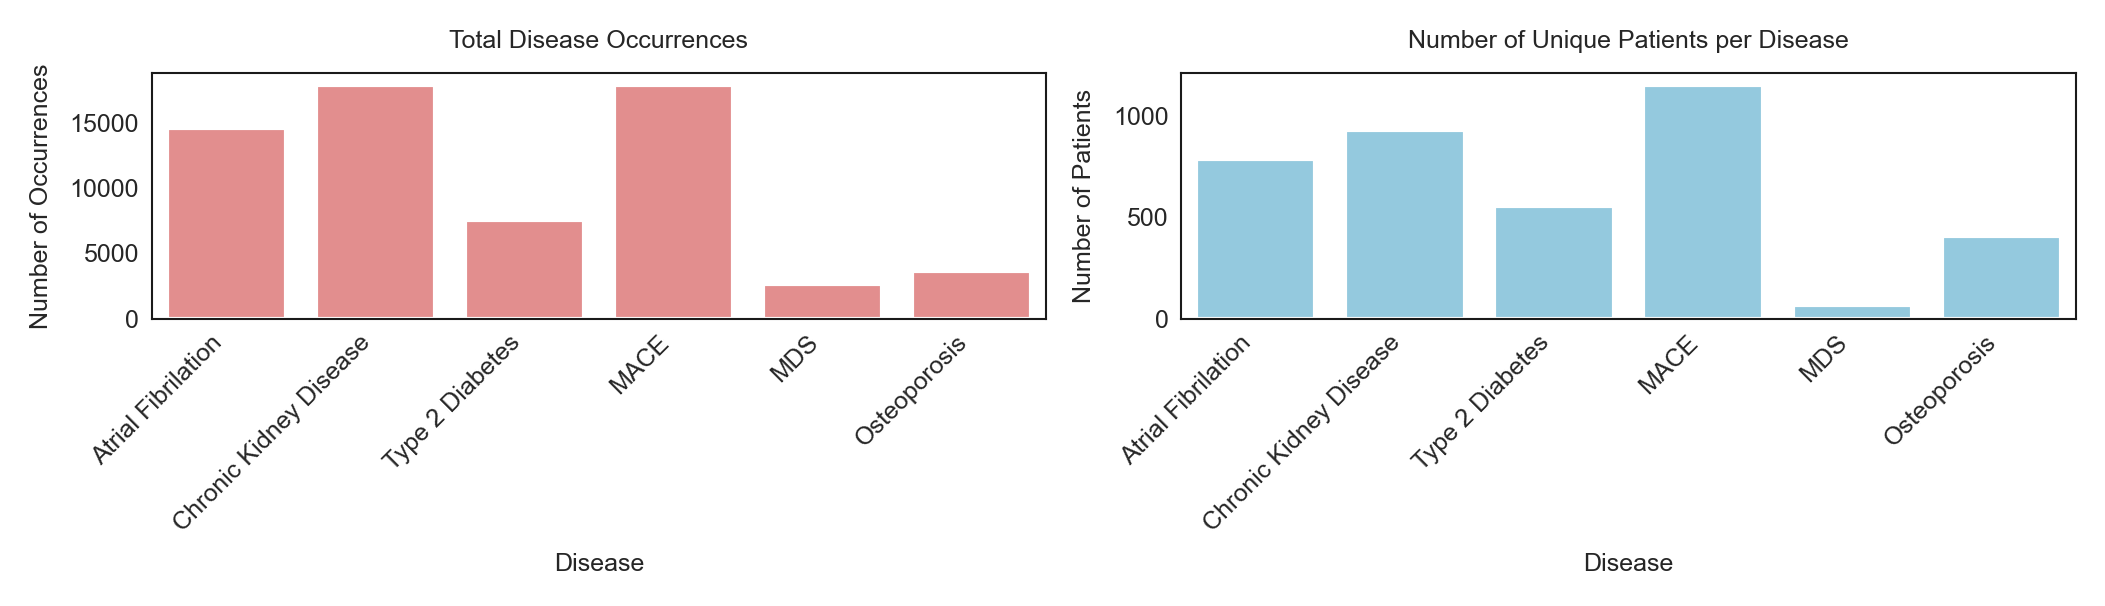

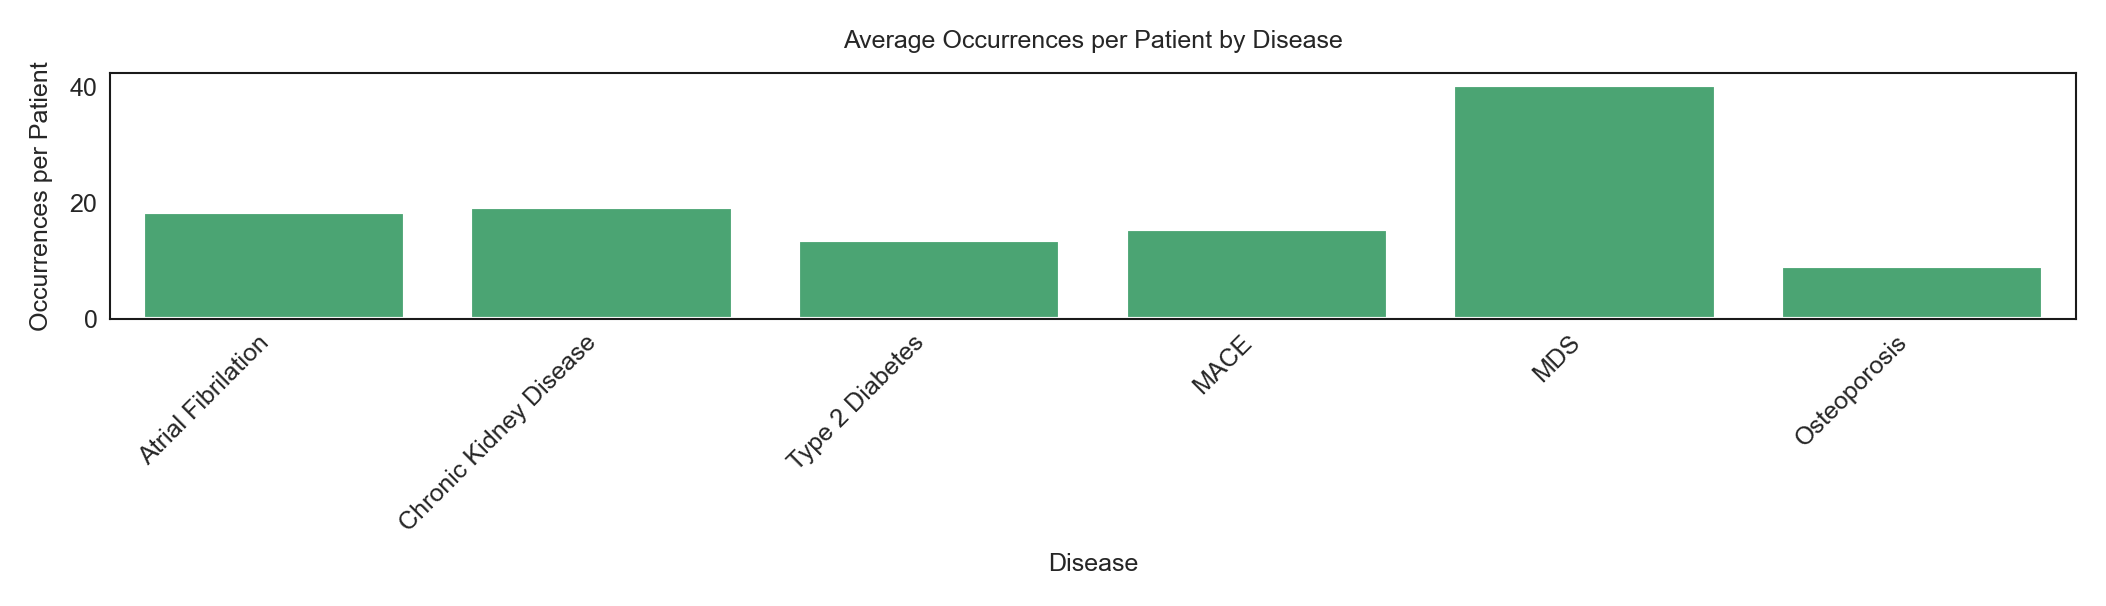

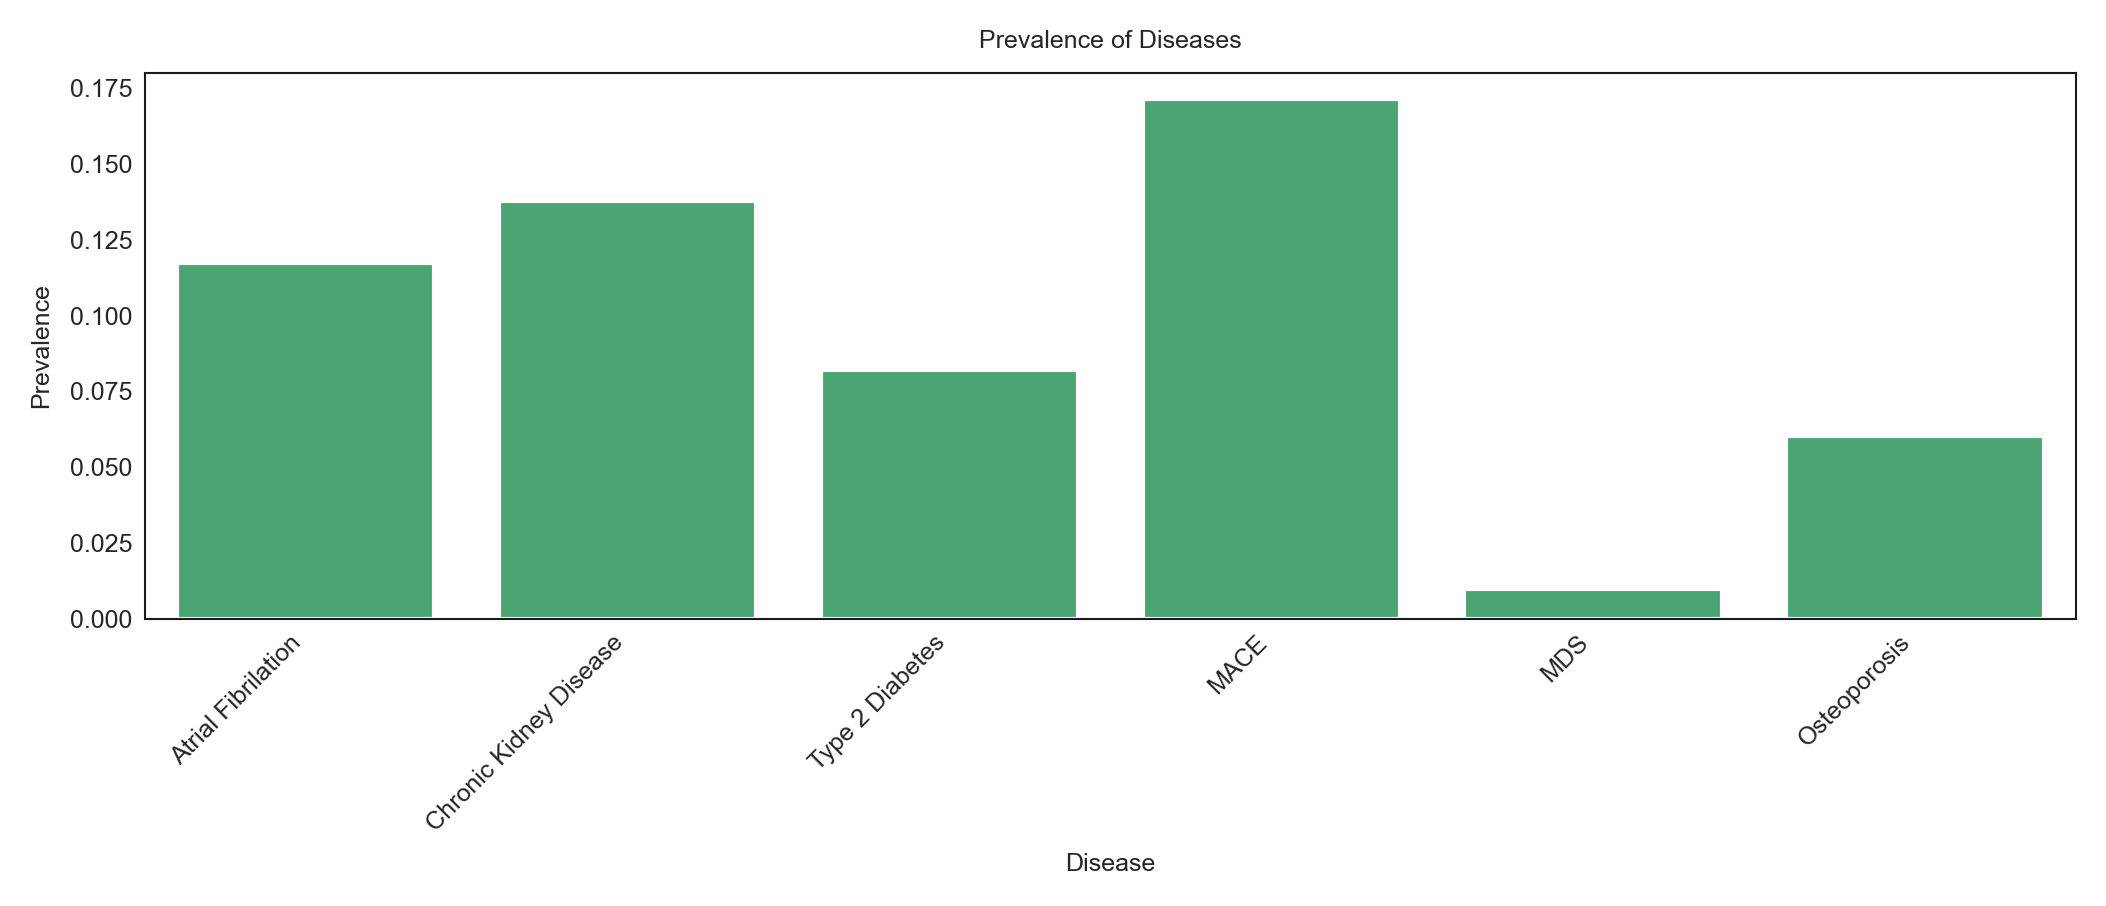

In [90]:

# Create a DataFrame with both sets of numbers
disease_data = pd.DataFrame({
    'Disease': ['Atrial Fibrilation', 'Chronic Kidney Disease', 'Type 2 Diabetes', 
               'MACE', 'MDS', 'Osteoporosis'],
    'Unique Patients': [791, 930, 554, 1156, 66, 406],
    'Total Occurrences': [14552, 17907, 7521, 17869, 2666, 3652],
    'Prevalence': [0.11737646535094227, 0.13800267101943908, 0.08220804273631102, 0.1715388039768511,
                  0.009793737943315032, 0.060246327348271254]
})

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2)

# Plot 2: Total Occurrences
sns.barplot(data=disease_data, x='Disease', y='Total Occurrences', ax=ax1, color='lightcoral')
ax1.set_title('Total Disease Occurrences')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylabel('Number of Occurrences')


# Plot 1: Unique Patients
sns.barplot(data=disease_data, x='Disease', y='Unique Patients', ax=ax2, color='skyblue')
ax2.set_title('Number of Unique Patients per Disease')
ax2.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax2.set_ylabel('Number of Patients')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Optional: Create a ratio plot (occurrences per patient)
plt.figure()
disease_data['Occurrences per Patient'] = disease_data['Total Occurrences'] / disease_data['Unique Patients']
sns.barplot(data=disease_data, x='Disease', y='Occurrences per Patient', color='mediumseagreen')
plt.title('Average Occurrences per Patient by Disease')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Occurrences per Patient')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3))
sns.barplot(data=disease_data, x='Disease', y='Prevalence', color='mediumseagreen')
plt.title('Prevalence of Diseases')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Prevalence')
plt.tight_layout()
plt.show()

In [ ]:
mortal